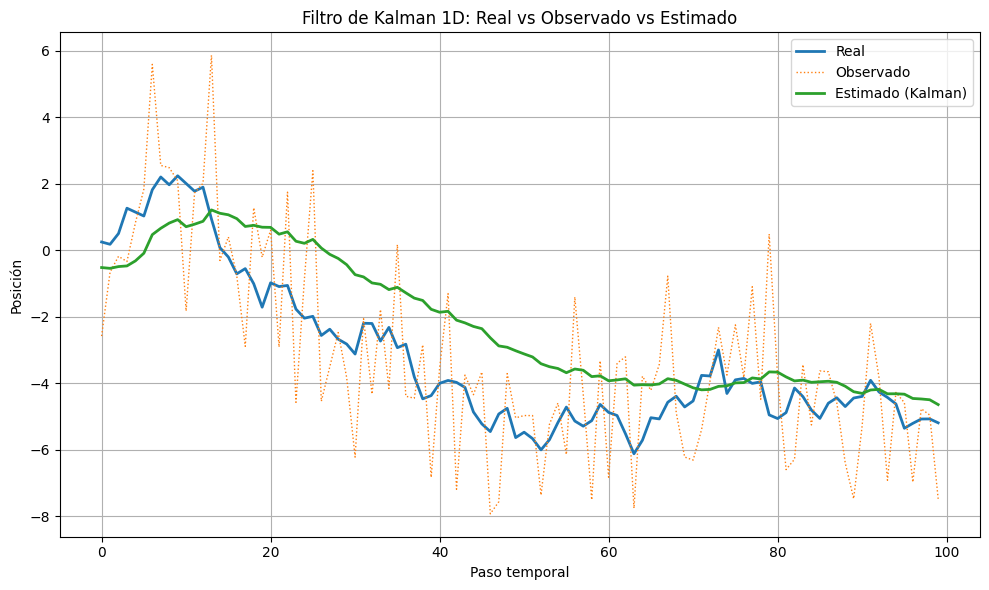

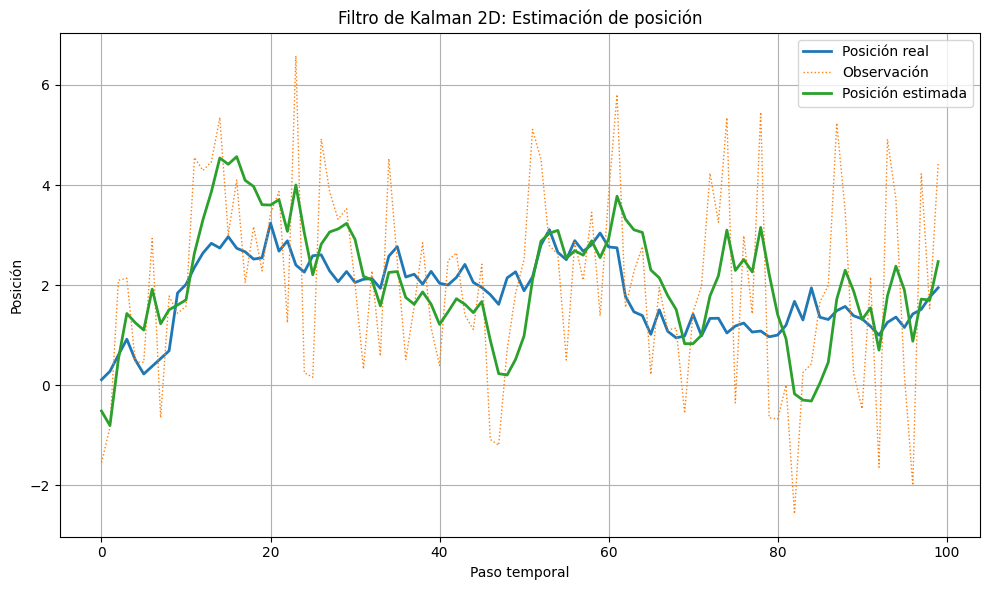

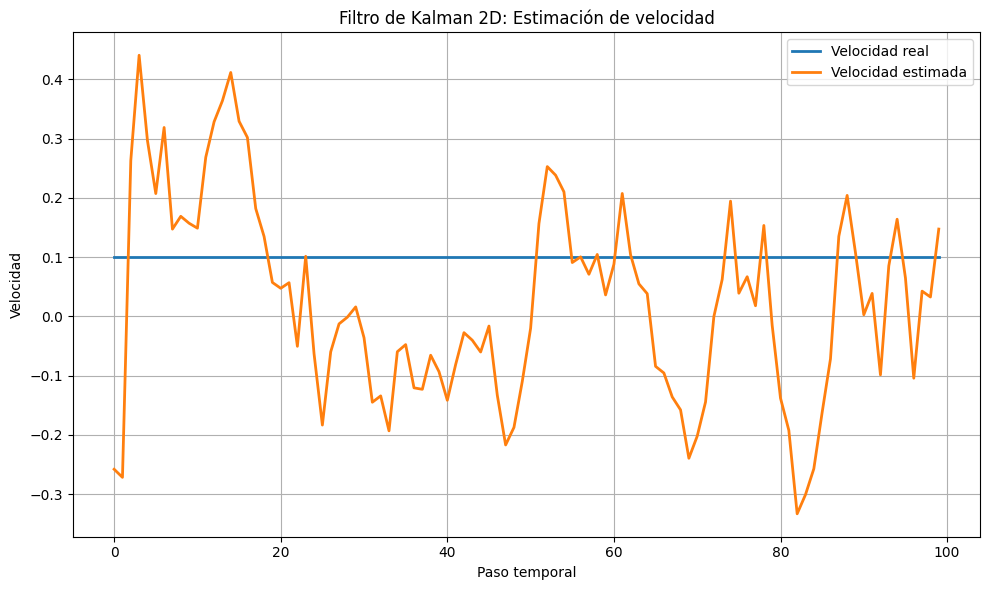

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter1D:
    def __init__(self, Q=1e-3, R=4.0, x0=0.0, P0=1.0):
        """
        Q: process noise covariance
        R: measurement noise covariance
        x0: initial state estimate
        P0: initial estimate covariance
        """
        self.Q = Q
        self.R = R
        self.x_hat = x0
        self.P = P0

    def update(self, z):
        # Prediction step
        x_prior = self.x_hat
        P_prior = self.P + self.Q

        # Kalman gain
        K = P_prior / (P_prior + self.R)

        # Correction step
        self.x_hat = x_prior + K * (z - x_prior)
        self.P = (1 - K) * P_prior

        return self.x_hat

# Generar datos sintéticos
np.random.seed(42)
n = 100
real_pos = np.cumsum(np.random.randn(n) * 0.5)  # verdadera con pasos pequeños
noise = np.random.normal(0, 2.0, size=n)
observed = real_pos + noise

# Filtro de Kalman 1D
kf = KalmanFilter1D(Q=0.01, R=4.0, x0=0.0, P0=1.0)
estimated = [kf.update(z) for z in observed]

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(real_pos, label='Real', linewidth=2)
plt.plot(observed, label='Observado', linestyle=':', linewidth=1)
plt.plot(estimated, label='Estimado (Kalman)', linewidth=2)
plt.title('Filtro de Kalman 1D: Real vs Observado vs Estimado')
plt.xlabel('Paso temporal')
plt.ylabel('Posición')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Extensión a 2D: posición y velocidad constantes
class KalmanFilter2D:
    def __init__(self, dt=1.0, Q_std=1e-2, R_std=2.0):
        """
        dt: intervalo de muestreo
        Q_std: desviación del ruido de proceso
        R_std: desviación del ruido de medición
        """
        # Estado: [pos, vel]^T
        self.F = np.array([[1, dt],
                           [0, 1]])
        self.H = np.array([[1, 0]])
        self.Q = (Q_std ** 2) * np.eye(2)
        self.R = np.array([[R_std ** 2]])
        self.x = np.zeros((2,1))  # estado inicial
        self.P = np.eye(2)

    def update(self, z):
        # Predicción
        x_prior = self.F @ self.x
        P_prior = self.F @ self.P @ self.F.T + self.Q

        # Ganancia de Kalman
        S = self.H @ P_prior @ self.H.T + self.R
        K = P_prior @ self.H.T @ np.linalg.inv(S)

        # Corrección
        y = np.array([[z]]) - (self.H @ x_prior)
        self.x = x_prior + K @ y
        self.P = (np.eye(2) - K @ self.H) @ P_prior

        return self.x.flatten()

# Datos sintéticos 2D
real_pos2 = np.cumsum(np.random.randn(n) * 0.3)
real_vel2 = np.ones(n) * 0.1  # velocidad constante
observed2 = real_pos2 + np.random.normal(0, 2.0, size=n)

kf2 = KalmanFilter2D(dt=1.0, Q_std=0.1, R_std=2.0)
est2 = np.array([kf2.update(z) for z in observed2])

# Gráfica 2D
plt.figure(figsize=(10, 6))
plt.plot(real_pos2, label='Posición real', linewidth=2)
plt.plot(observed2, label='Observación', linestyle=':', linewidth=1)
plt.plot(est2[:, 0], label='Posición estimada', linewidth=2)
plt.title('Filtro de Kalman 2D: Estimación de posición')
plt.xlabel('Paso temporal')
plt.ylabel('Posición')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualización de velocidad estimada
plt.figure(figsize=(10, 6))
plt.plot(real_vel2, label='Velocidad real', linewidth=2)
plt.plot(est2[:, 1], label='Velocidad estimada', linewidth=2)
plt.title('Filtro de Kalman 2D: Estimación de velocidad')
plt.xlabel('Paso temporal')
plt.ylabel('Velocidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()